## Regularization

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_moons

import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras import regularizers

In [2]:
x, y = make_moons(n_samples=200, noise=0.2, random_state=149)
x.shape

(200, 2)

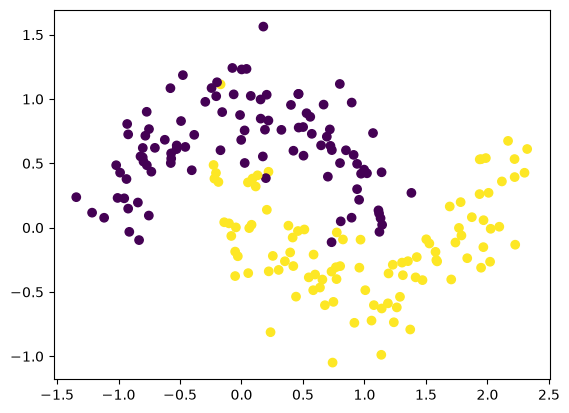

In [3]:
plt.scatter(x[:,0], x[:,1], c=y)
plt.show()

### Without Regularization

In [4]:
model = Sequential()

model.add(Dense(128, input_dim=2, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(metrics=['accuracy'], loss='binary_crossentropy', optimizer='Adam')
history = model.fit(x, y, epochs=2000, verbose=0, validation_split=0.2)

D:\Deep Learning\dl\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


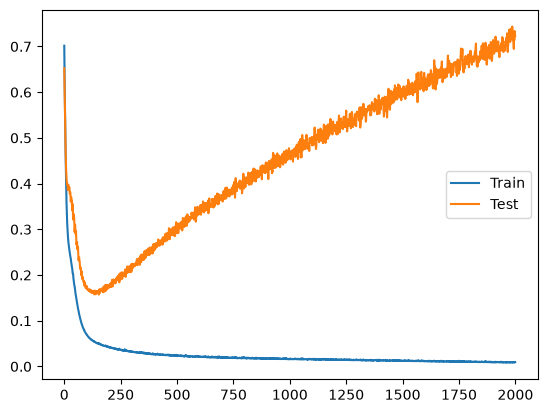

In [5]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')

plt.legend()
plt.show()

### With Regularization

In [10]:
model1 = Sequential()

model1.add(Dense(128, input_dim=2, activation='relu', kernel_regularizer=regularizers.l2(0.1))) # l2
model1.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.1)))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(metrics=['accuracy'], loss='binary_crossentropy', optimizer='Adam')
history1 = model1.fit(x, y, epochs=2000, verbose=0, validation_split=0.2)

D:\Deep Learning\dl\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


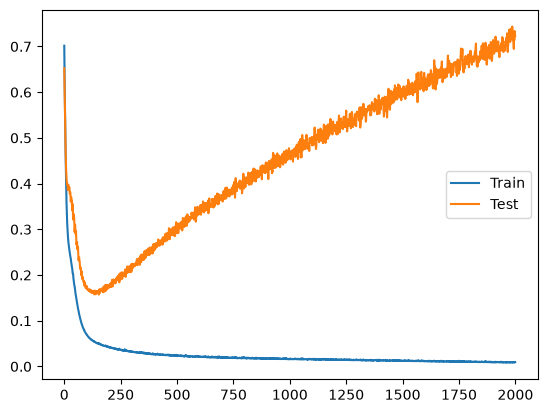

In [11]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')

plt.legend()
plt.show()

In [14]:
model2 = Sequential()

model2.add(Dense(128, input_dim=2, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.5, l2=0.5)))
model2.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.5, l2=0.5)))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(metrics=['accuracy'], loss='binary_crossentropy', optimizer='Adam')
history2 = model2.fit(x, y, epochs=2000, verbose=0, validation_split=0.2)

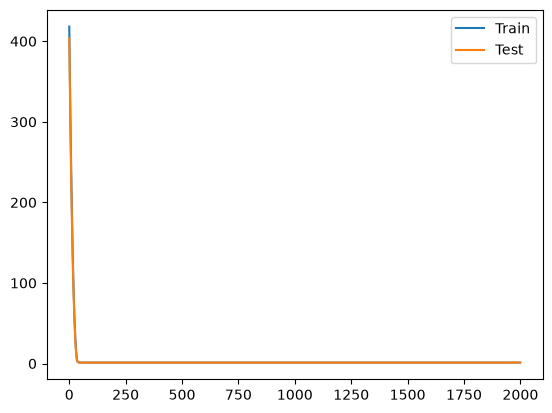

In [16]:
plt.plot(history2.history['loss'], label='Train')
plt.plot(history2.history['val_loss'], label='Test')

plt.legend()
plt.show()